In [219]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from warnings import filterwarnings
filterwarnings("ignore")


In [220]:
df= pd.read_csv("/content/Class 27_cancer.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
4,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.1127,0.07400,0.1794,0.05742,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.880,27.66,153.20,1606.0,0.14420,0.25760,0.3784,0.1932,0.3063,0.08368,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,926125,M,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.3174,0.14740,0.2149,0.06879,0.9622,1.0260,8.758,118.80,0.006399,0.04310,0.07845,0.02624,0.02057,0.006213,24.290,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.2542,0.2929,0.09873,NaN
469,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.2439,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
470,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.1440,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
471,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.3514,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [221]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [222]:
df.drop("Unnamed: 32",axis=1,inplace=True)

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       473 non-null    int64  
 1   diagnosis                473 non-null    object 
 2   radius_mean              473 non-null    float64
 3   texture_mean             473 non-null    float64
 4   perimeter_mean           473 non-null    float64
 5   area_mean                473 non-null    float64
 6   smoothness_mean          473 non-null    float64
 7   compactness_mean         473 non-null    float64
 8   concavity_mean           473 non-null    float64
 9   concave points_mean      473 non-null    float64
 10  symmetry_mean            473 non-null    float64
 11  fractal_dimension_mean   473 non-null    float64
 12  radius_se                473 non-null    float64
 13  texture_se               473 non-null    float64
 14  perimeter_se             4

In [224]:
object_col = df.select_dtypes(include=['object']).columns.to_list()
object_col

['diagnosis']

In [225]:
li = LabelEncoder()

In [226]:
for col in object_col:
  print(f"{col} : {df[col].unique()}")




diagnosis : ['M' 'B']


In [227]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,116


In [228]:
df['diagnosis']=li.fit_transform(df['diagnosis'])

In [229]:
df.drop("id",axis=1,inplace=True)

In [230]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
4,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.1127,0.07400,0.1794,0.05742,0.4467,0.7732,3.180,53.91,0.004314,0.01382,0.02254,0.01039,0.01369,0.002179,22.880,27.66,153.20,1606.0,0.14420,0.25760,0.3784,0.1932,0.3063,0.08368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,1,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.3174,0.14740,0.2149,0.06879,0.9622,1.0260,8.758,118.80,0.006399,0.04310,0.07845,0.02624,0.02057,0.006213,24.290,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.2542,0.2929,0.09873
469,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.2439,0.13890,0.1726,0.05623,1.1760,1.2560,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
470,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.1440,0.09791,0.1752,0.05533,0.7655,2.4630,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
471,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.3514,0.15200,0.2397,0.07016,0.7260,1.5950,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [231]:
y = df.iloc[:,0]
x = df.iloc[:,1:]

In [232]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [233]:
st = SMOTE(random_state=42)

x_train_smote, y_train_smote = st.fit_resample(x_train, y_train)

In [234]:
y_train_smote.value_counts()

,count
diagnosis,
1,286
0,286


In [235]:
from sklearn.ensemble import VotingClassifier

In [236]:
estimator = {
    'lr': LogisticRegression(max_iter=1000),
    'svm': SVC(probability=True),
    'dt': DecisionTreeClassifier(),
    'rf': RandomForestClassifier()
}

In [237]:
model = VotingClassifier(estimators=list(estimator.items()), voting='soft')

In [238]:
for name, model1 in estimator.items():
  score = cross_val_score(model1, x, y, cv=5, scoring='accuracy')
  print(f"Model:{name} : accuricy:{score.mean():.2f}")


Model:lr : accuricy:0.99
Model:svm : accuricy:1.00
Model:dt : accuricy:0.99
Model:rf : accuricy:1.00


In [239]:
model.fit(x_train_smote,y_train_smote)

model.score(x_train_smote,y_train_smote)

1.0

In [240]:
model.score(x_test,y_test)

0.9894736842105263

In [241]:
y_praid = model.predict(x_test)

In [242]:
y_praid

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0])

In [243]:
print(classification_report(y_test,y_praid))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        71
           1       0.96      1.00      0.98        24

    accuracy                           0.99        95
   macro avg       0.98      0.99      0.99        95
weighted avg       0.99      0.99      0.99        95



<Axes: >

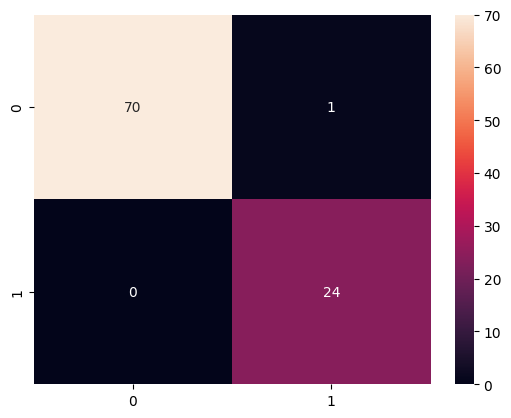

In [244]:
sns.heatmap(confusion_matrix(y_test,y_praid),annot=True)

In [245]:
new_data_str = "7.76/t24.54/t47.92/t181.0/t0.05263/t0.04362/t0.0000/t0.00000/t0.1587/t0.05884/t0.3857/t1.4280/t2.548/t19.15/t0.007189/t0.00466/t0.00000/t0.00000/t0.02676/t0.002783/t9.456/t30.37/t59.16/t268.6/t0.08996/t0.06444/t0.0000/t0.0000/t0.2871/t0.07039"


new_data_values = [float(val) for val in new_data_str.split('/t')]


new_data_df = pd.DataFrame([new_data_values], columns=x.columns)

predictions_on_unknown_data = model.predict(new_data_df)

print("Input Data:")
print(new_data_df)
print("\nPredictions for the provided data (0 = Benign, 1 = Malignant):")
print(predictions_on_unknown_data)

Input Data:
   radius_mean  texture_mean  ...  symmetry_worst  fractal_dimension_worst
0         7.76         24.54  ...          0.2871                  0.07039

[1 rows x 30 columns]

Predictions for the provided data (0 = Benign, 1 = Malignant):
[0]


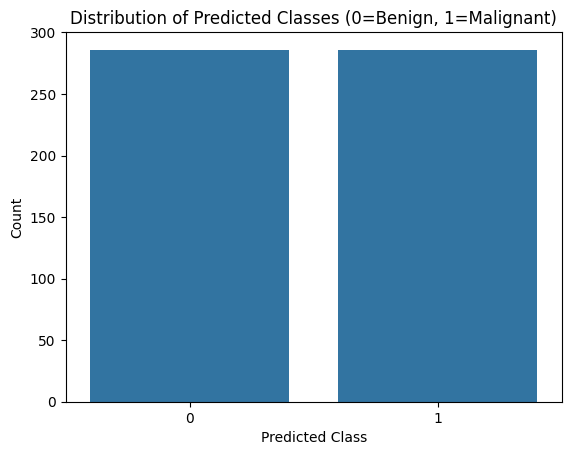

In [246]:

sns.countplot(x=model.predict(x_train_smote))
plt.title('Distribution of Predicted Classes (0=Benign, 1=Malignant)')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
plt.show()